<a href="https://colab.research.google.com/github/aryaganu10-cpu/GenAi/blob/main/GenAi__task13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/fraud_transactions.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Inspect the data types and missing values
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,trans_date_trans_time,merchant,category,amt,gender,state,job,is_fraud
0,2/27/19 21:32,"fraud_Langosh, Wintheiser and Hyatt",food_dining,83.64,F,TX,"Physicist, medical",0
1,2/13/19 19:41,fraud_Dibbert and Sons,entertainment,79.13,M,PA,Secretary/administrator,0
2,1/11/19 20:03,"fraud_McDermott, Osinski and Morar",home,12.02,F,CA,"Buyer, industrial",0
3,1/20/19 9:08,fraud_Bauch-Raynor,grocery_pos,84.41,M,TN,Clothing/textile technologist,0
4,1/4/19 17:04,"fraud_Reichert, Huels and Hoppe",shopping_net,2.81,F,ME,Financial trader,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6486 entries, 0 to 6485
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  6486 non-null   object 
 1   merchant               6486 non-null   object 
 2   category               6486 non-null   object 
 3   amt                    6486 non-null   float64
 4   gender                 6486 non-null   object 
 5   state                  6486 non-null   object 
 6   job                    6486 non-null   object 
 7   is_fraud               6486 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 405.5+ KB


In [2]:
# Convert 'trans_date_trans_time' to datetime objects
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Display info to confirm the change
df.info()


/tmp/ipykernel_248/1936537310.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6486 entries, 0 to 6485
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   trans_date_trans_time  6486 non-null   datetime64[ns]
 1   merchant               6486 non-null   object        
 2   category               6486 non-null   object        
 3   amt                    6486 non-null   float64       
 4   gender                 6486 non-null   object        
 5   state                  6486 non-null   object        
 6   job                    6486 non-null   object        
 7   is_fraud               6486 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 405.5+ KB


In [3]:
# Convert 'trans_date_trans_time' to datetime objects
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

# Display info to confirm the change
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6486 entries, 0 to 6485
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   trans_date_trans_time  6486 non-null   datetime64[ns]
 1   merchant               6486 non-null   object        
 2   category               6486 non-null   object        
 3   amt                    6486 non-null   float64       
 4   gender                 6486 non-null   object        
 5   state                  6486 non-null   object        
 6   job                    6486 non-null   object        
 7   is_fraud               6486 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 405.5+ KB


In [4]:
!pip install sdv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.2 MB/s eta 0:00:00


In [5]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# Initialize metadata and detect from dataframe
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# Initialize synthesizer and fit
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df)

# Generate synthetic data
synthetic_df = synthesizer.sample(num_rows=5000)

# Display first few rows
print("Synthetic Data Head:")
display(synthetic_df.head())

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Synthetic Data Head:


,trans_date_trans_time,merchant,category,amt,gender,state,job,is_fraud
0,2019-02-13 08:37:57,fraud_Kuphal-Bartoletti,grocery_pos,180.87,F,Kansas,Toxicologist,0
1,2019-01-18 12:21:14,fraud_Tillman LLC,misc_pos,39.67,M,Louisiana,Agricultural consultant,0
2,2019-02-11 06:48:11,fraud_Pacocha-O'Reilly,gas_transport,10.48,F,New Hampshire,Counsellor,0
3,2019-03-03 10:57:52,fraud_Bogisich-Homenick,shopping_pos,48.74,M,Maryland,Medical sales representative,0
4,2019-01-24 01:09:29,fraud_Weber and Sons,home,136.53,F,Ohio,Further education lecturer,0


In [6]:
import warnings
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# Suppress warnings to ensure clean execution output
warnings.filterwarnings("ignore")

# Initialize metadata and detect from dataframe
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# Initialize synthesizer and fit
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df)

# Generate synthetic data
synthetic_df = synthesizer.sample(num_rows=5000)

# Display first few rows
print("Synthetic Data Head:")
display(synthetic_df.head())

Synthetic Data Head:


,trans_date_trans_time,merchant,category,amt,gender,state,job,is_fraud
0,2019-02-13 08:37:57,fraud_Kuphal-Bartoletti,grocery_pos,180.87,F,Kansas,Toxicologist,0
1,2019-01-18 12:21:14,fraud_Tillman LLC,misc_pos,39.67,M,Louisiana,Agricultural consultant,0
2,2019-02-11 06:48:11,fraud_Pacocha-O'Reilly,gas_transport,10.48,F,New Hampshire,Counsellor,0
3,2019-03-03 10:57:52,fraud_Bogisich-Homenick,shopping_pos,48.74,M,Maryland,Medical sales representative,0
4,2019-01-24 01:09:29,fraud_Weber and Sons,home,136.53,F,Ohio,Further education lecturer,0


In [7]:
from sdv.evaluation.single_table import evaluate_quality

# 1. Descriptive Statistics
print("Original Data Descriptive Statistics:")
display(df.describe())
print("\nSynthetic Data Descriptive Statistics:")
display(synthetic_df.describe())

# 2. Correlation Matrices
print("\nOriginal Data Correlation Matrix:")
display(df.corr(numeric_only=True))
print("\nSynthetic Data Correlation Matrix:")
display(synthetic_df.corr(numeric_only=True))

# 3. Evaluate Quality using SDV
print("\nEvaluating Synthetic Data Quality...")
quality_report = evaluate_quality(
    real_data=df,
    synthetic_data=synthetic_df,
    metadata=metadata
)

# 4. Print Score
print(f"\nOverall Quality Score: {quality_report.get_score()}")

Original Data Descriptive Statistics:


,trans_date_trans_time,amt,is_fraud
count,6486,6486.000000,6486.000000
mean,2019-01-30 18:08:47.382053632,101.700956,0.074931
min,2019-01-01 00:36:00,1.000000,0.000000
25%,2019-01-15 13:30:15,12.572500,0.000000
50%,2019-01-30 07:24:30,52.080000,0.000000
75%,2019-02-13 18:45:15,91.945000,0.000000
max,2019-03-03 21:31:00,2312.210000,1.000000
std,NaN,189.292632,0.263300



Synthetic Data Descriptive Statistics:


,trans_date_trans_time,amt,is_fraud
count,5000,5000.000000,5000.000000
mean,2019-01-30 01:56:33.093400064,97.542546,0.077600
min,2019-01-01 00:41:58,1.000000,0.000000
25%,2019-01-15 06:01:47.500000,13.757500,0.000000
50%,2019-01-29 13:56:26.500000,49.185000,0.000000
75%,2019-02-13 06:56:56,131.787500,0.000000
max,2019-03-03 21:31:00,1300.210000,1.000000
std,NaN,129.075388,0.267568



Original Data Correlation Matrix:


,amt,is_fraud
amt,1.00000,0.62973
is_fraud,0.62973,1.00000



Synthetic Data Correlation Matrix:


,amt,is_fraud
amt,1.00000,0.15603
is_fraud,0.15603,1.00000



Evaluating Synthetic Data Quality...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 55.61it/s]|
Column Shapes Score: 93.96%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 55.64it/s]|
Column Pair Trends Score: 56.36%

Overall Score (Average): 75.16%


Overall Quality Score: 0.751605813742909


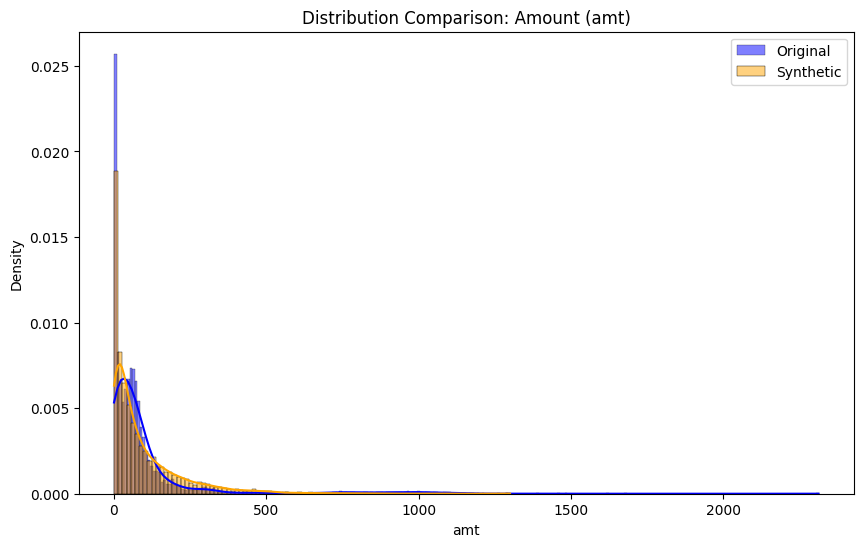

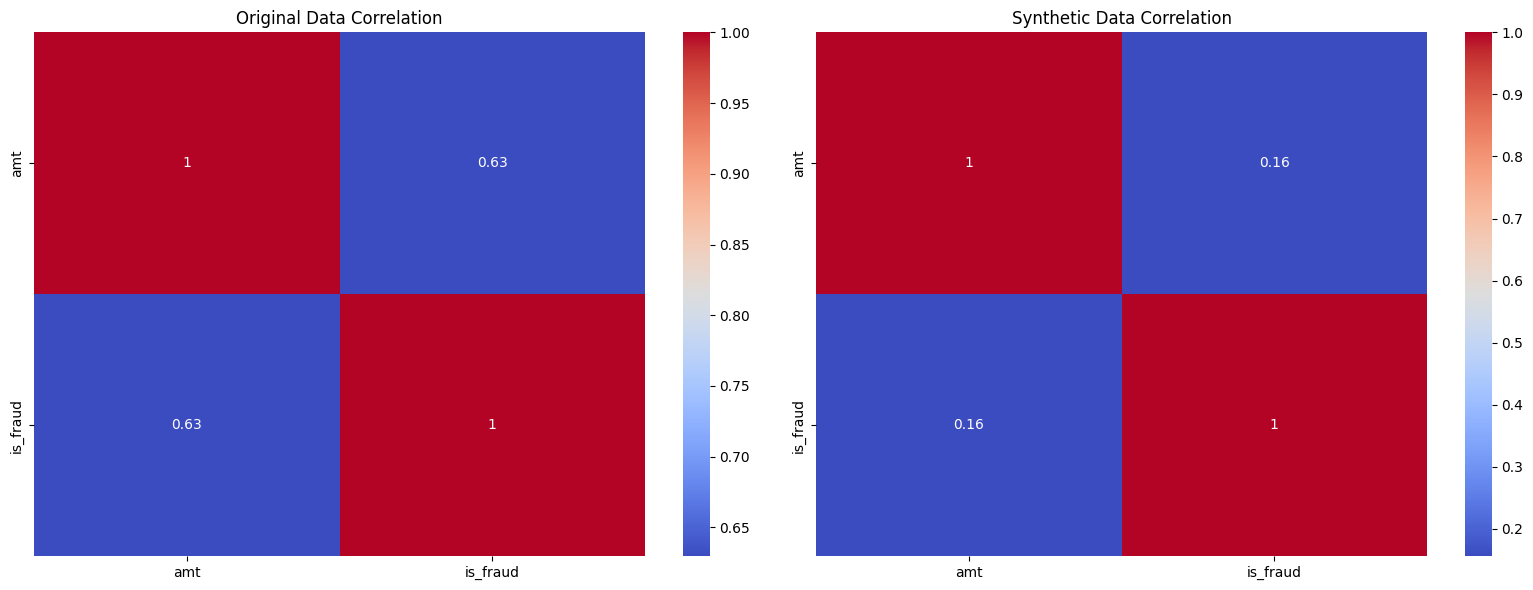

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compare Distribution of 'amt' column
plt.figure(figsize=(10, 6))
sns.histplot(df['amt'], color='blue', label='Original', kde=True, stat="density", alpha=0.5)
sns.histplot(synthetic_df['amt'], color='orange', label='Synthetic', kde=True, stat="density", alpha=0.5)
plt.title('Distribution Comparison: Amount (amt)')
plt.legend()
plt.show()

# 2. Compare Correlation Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original Data Correlation
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Original Data Correlation')

# Synthetic Data Correlation
sns.heatmap(synthetic_df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Synthetic Data Correlation')

plt.tight_layout()
plt.show()